In [1]:
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
from scipy import special
from tqdm import tqdm
from math import floor
import statsmodels.api as sm

# 1. Генерация данных

In [2]:
def gen():
    return int(np.random.random() * 10**6)

In [97]:
def generator_uniform(n):
    return np.random.uniform(-np.sqrt(3), np.sqrt(3), n)

def generator_normal(n):
    return np.random.normal(0, 1, n)

def generator_exponential(n):
    return stats.expon(scale=1, loc=-1).rvs(size=n, random_state=gen())

In [98]:
n = 100; N = 10**3
delta = 0.2

In [99]:
data = {
    "uniform" : [generator_uniform(n) for _ in range(N)],
    "normal" : [generator_normal(n) for _ in range(N)],
    "exponential" : [generator_exponential(n) for _ in range(N)]
}

# 2. Вычисление автокорреляционной функции

In [100]:
def get_autocorr_coef(array, lag):
    assert(lag < array.size - 1)

    inaccuracy = np.random.uniform(-delta, delta, n)
    return stats.pearsonr(array[lag:] + inaccuracy[lag:], array[:-lag] + inaccuracy[:-lag])

def get_autocorr_coefs(array):
    return np.array([
        get_autocorr_coef(array, lag)[0] for lag in range(1, array.size - 1)
    ])

In [101]:
autocorr_coefs = {
    key : [get_autocorr_coefs(array) for array in tqdm(data[key])] for key in data.keys()
}

100%|██████████| 1000/1000 [00:44<00:00, 22.25it/s]


In [102]:
autocorr_coefs_min = {
    key : np.array([np.array(autocorr_coefs[key])[:, i].min() for i in range(n - 2)]) for key in data.keys()
}

autocorr_coefs_max = {
    key : np.array([np.array(autocorr_coefs[key])[:, i].max() for i in range(n - 2)]) for key in data.keys()
}

(-1.0, 1.0)

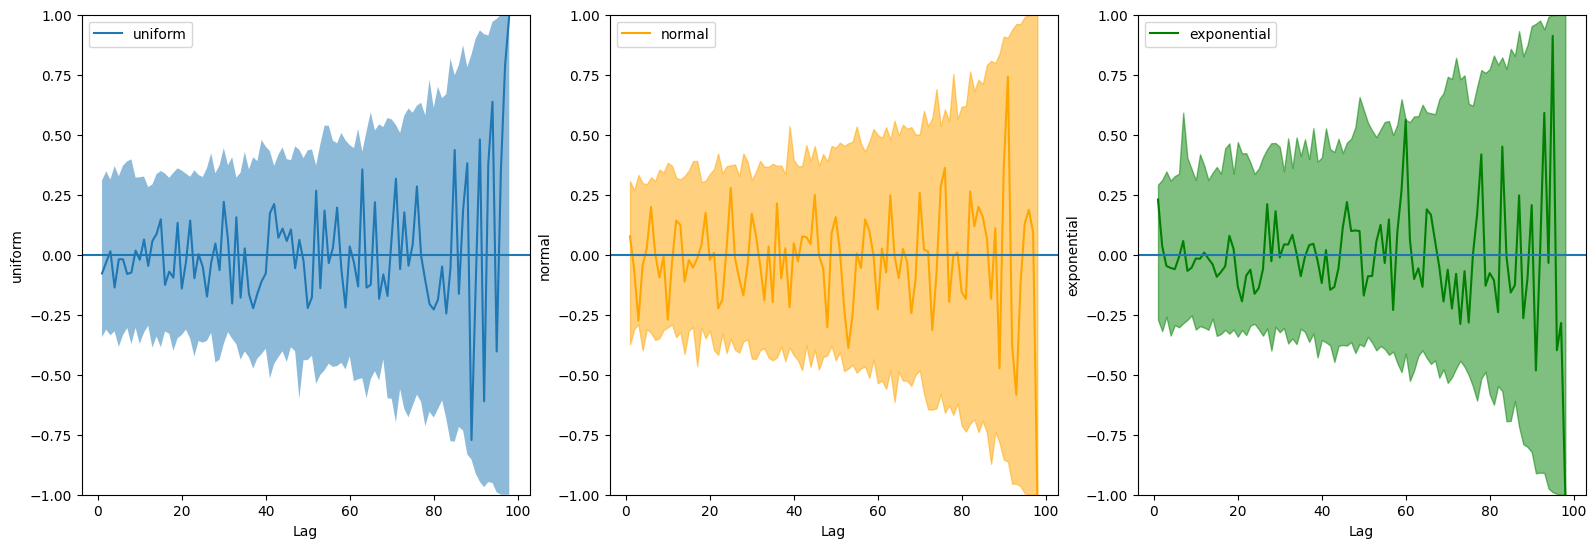

In [103]:
fig = plt.figure(figsize=(16, 6))

cell_width = 0.28
cell_height = 0.8
h_spacing = 0.05
bottom_margin = 0.1

ax1 = plt.axes([0.07, bottom_margin, cell_width, cell_height])
ax2 = plt.axes([0.07 + cell_width + h_spacing, bottom_margin, cell_width, cell_height])
ax3 = plt.axes([0.07 + 2*(cell_width + h_spacing), bottom_margin, cell_width, cell_height])

plt.sca(ax1)
key = "uniform"
sns.lineplot({key : autocorr_coefs[key][0], "Lag" : list(range(1, n - 1))}, y=key, x="Lag", label=key)
plt.fill_between(list(range(1, n - 1)), autocorr_coefs_min[key], autocorr_coefs_max[key], alpha=0.5)
plt.axhline(0)
plt.ylim(-1, 1)

plt.sca(ax2)
key = "normal"
sns.lineplot({key : autocorr_coefs[key][0], "Lag" : list(range(1, n - 1))}, y=key, x="Lag", label=key, color="orange")
plt.fill_between(list(range(1, n - 1)), autocorr_coefs_min[key], autocorr_coefs_max[key], alpha=0.5, color="orange")
plt.axhline(0)
plt.ylim(-1, 1)

plt.sca(ax3)
key = "exponential"
sns.lineplot({key : autocorr_coefs[key][0], "Lag" : list(range(1, n - 1))}, y=key, x="Lag", label=key, color="green")
plt.fill_between(list(range(1, n - 1)), autocorr_coefs_min[key], autocorr_coefs_max[key], alpha=0.5, color="green")
plt.axhline(0)
plt.ylim(-1, 1)

# 3. Начиная с какого $\tau$ ноль?